## Course Enrollment Consistency Across Quarters and Years

The question we are trying to explore in this section is: **"Do enrollment fill rates vary more between quarters (Fall vs Winter vs Spring) or within the same quarter across years?"** 

We investigate whether enrollment behavior for a given course is more consistent within the same quarter across different years or across all quarters combined. Specifically, we examine whether the variability in early enrollment metrics is greater overall or within individual quarters.

Understanding this distinction is important for prediction. If enrollment behavior is more consistent within the same quarter across years, then quarter-specific historical data may provide stronger signals when forecasting demand. For example, when predicting enrollment for a course in Winter 2025, it may be more informative to look at previous Winter offerings of that course rather than considering all past offerings equally.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df = pd.read_csv('revised_course_enrolment_clean.csv')

In [266]:
import warnings
warnings.filterwarnings("ignore")


In [172]:
df.shape

(658, 15)

In [286]:
print("Number of quarters examined:", df["quarter"].nunique())
print("Number of courses examined:", df["subj_course_id"].nunique())


Number of quarters examined: 9
Number of courses examined: 145


In [288]:
print("List of courses in the dataset")
print(df["subj_course_id"].unique())

List of courses in the dataset
['COGS 101B' 'COGS 101A' 'COGS 9' 'COGS 100' 'COGS 110' 'COGS 111'
 'COGS 112' 'COGS 107B' 'COGS 18' 'COGS 163' 'COGS 165' 'COGS 187A'
 'COGS 13' 'COGS 169' 'COGS 11' 'COGS 10' 'COGS 15' 'COGS 14A' 'COGS 17'
 'COGS 14B' 'COGS 123' 'COGS 137' 'COGS 108' 'COGS 1' 'COGS 125'
 'COGS 118B' 'COGS 118A' 'COGS 116' 'COGS 8' 'COGS 107A' 'COGS 20'
 'COGS 12' 'COGS 143' 'COGS 153' 'COGS 3' 'COGS 120' 'COGS 124'
 'COGS 101C' 'COGS 2' 'COGS 115' 'COGS 189' 'COGS 172' 'COGS 187B'
 'COGS 181' 'COGS 156' 'COGS 118C' 'COGS 126' 'COGS 127' 'COGS 177'
 'COGS 164' 'COGS 150' 'COGS 188' 'COGS 155' 'COGS 144' 'COGS 122'
 'COGS 107C' 'COGS 142' 'COGS 185' 'COGS 184' 'COGS 179' 'COGS 138'
 'MATH 130' 'MATH 142A' 'MATH 103A' 'MATH 181B' 'MATH 4C' 'MATH 31AH'
 'MATH 96' 'MATH 180C' 'MATH 180A' 'MATH 109' 'MATH 2' 'MATH 191'
 'MATH 18' 'MATH 153' 'MATH 184' 'MATH 187A' 'MATH 144' 'MATH 104A'
 'MATH 183' 'MATH 154' 'MATH 3C' 'MATH 3B' 'MATH 173A' 'MATH 20C'
 'MATH 11' 'MATH 20B' 'MA

In [290]:
print("List of quarters in the dataset")
print(df["quarter"].unique())

List of quarters in the dataset
['Fa24' 'Fa23' 'Fa22' 'Wi23' 'Wi24' 'Wi25' 'Sp25' 'Sp23' 'Sp24']


In [291]:
# Extract the season(quarter name) ex: 'Fa' from 'Fa22'
df["season"] = df["quarter"].str[:2]

### Filtering

To explore this question, we first identify courses that are offered consistently across quarters and years. Comparing variability across quarters requires courses with stable offering patterns, so we focus on courses that follow consistent schedules across the dataset.

First, we identify courses that are offered in all three quarters (Fall, Winter, and Spring) each year. These courses allow us to directly compare enrollment patterns across quarters.

In [228]:
def is_all_three_quarters(course_df):
    
    return (course_df["season"].nunique() == 3 and course_df["season"].value_counts()['Fa'] == 3 and course_df["season"].value_counts()['Wi'] == 3 and course_df["season"].value_counts()['Sp'] == 3 )

In [229]:
courses_all_three = df.groupby("subj_course_id").filter(is_all_three_quarters)

In [299]:
print("Number of 'all three quarters' = ", courses_all_three["subj_course_id"].nunique())

Number of 'all three quarters' =  22


In [301]:
courses_all_three

,fill_rate_0to12h,fill_rate_12to24h,fill_rate_24to36h,fill_rate_36to48h,fill_rate_48to60h,fill_rate_60to72h,quarter,dept,subj_course_id,start_time,end_time,final_waitlist_count,total_seats,final_waitlist_ratio,fill_rate_0to72h,season
1,1.25,0.25,0.42,0.08,0.00,0.00,Fa24,cogs,COGS 101A,2024-05-24 08:00:00,2024-09-26 06:00:00,23.0,336.0,0.068452,2.00,Fa
3,0.50,0.08,0.17,0.08,0.00,0.00,Fa24,cogs,COGS 100,2024-05-24 08:00:00,2024-09-26 06:00:00,1.0,300.0,0.003333,0.83,Fa
8,0.92,0.00,0.17,0.33,0.00,0.00,Fa24,cogs,COGS 18,2024-05-24 08:00:00,2024-09-26 06:00:00,75.0,630.0,0.119048,1.42,Fa
17,1.08,0.08,0.08,0.00,0.00,0.00,Fa24,cogs,COGS 14A,2024-05-24 08:00:00,2024-09-26 06:00:00,11.0,356.0,0.030899,1.24,Fa
18,0.83,0.17,0.17,-0.17,0.08,0.00,Fa24,cogs,COGS 17,2024-05-24 08:00:00,2024-09-26 06:00:00,19.0,414.0,0.045894,1.08,Fa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,0.08,0.00,0.00,-0.08,0.92,0.08,Sp24,math,MATH 170A,2024-02-17 08:00:00,2024-04-01 06:00:00,6.0,143.0,0.041958,1.00,Sp
647,3.83,0.25,0.00,0.08,0.42,0.25,Sp24,math,MATH 10B,2024-02-17 08:00:00,2024-04-01 06:00:00,4.0,838.0,0.004773,4.83,Sp
649,2.25,0.08,0.08,0.00,1.25,0.25,Sp24,math,MATH 10C,2024-02-17 08:00:00,2024-04-01 06:00:00,14.0,498.0,0.028112,3.91,Sp
653,2.75,0.25,0.08,0.08,0.67,0.08,Sp24,math,MATH 10A,2024-02-17 08:00:00,2024-04-01 06:00:00,18.0,468.0,0.038462,3.91,Sp


After applying this filter, we obtain a subset of 22 courses that maintain consistent quarterly offerings. This subset allows us to fairly compare enrollment variability within quarters and across quarters without being affected by inconsistent scheduling patterns.

### Stats

Next, we compute several measures of variability in early enrollment behavior for each course.

We calculate:
**Overall standard deviation**, which measures how much early enrollment varies across all offerings of the course.

**Within-quarter standard deviation**, which measures how much enrollment varies within the same quarter across different years.

**Seasonal mean standard deviation**, which captures how much the average enrollment differs between quarters.

These measures allow us to compare whether variability is primarily driven by differences across quarters or fluctuations within the same quarter across years.

In [230]:
def variability_stats(course_df):

    overall_std = course_df["fill_rate_0to72h"].std()

    season_std = course_df.groupby("season")["fill_rate_0to72h"].std()

    season_means = course_df.groupby("season")["fill_rate_0to72h"].mean()
    seasonal_mean_std = season_means.std()

    return pd.Series({
        "overall_std": overall_std,
        "within_fall_std": season_std.get("Fa"),
        "within_winter_std": season_std.get("Wi"),
        "within_spring_std": season_std.get("Sp"),
        "seasonal_mean_std": seasonal_mean_std
    })

In [268]:
table1_stats = courses_all_three.groupby("subj_course_id").apply(variability_stats)

In [269]:
table1_stats

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
subj_course_id,,,,,
COGS 1,1.762648,0.085049,0.407226,0.793032,1.968565
COGS 100,1.470607,1.168175,1.661606,0.040415,1.227945
COGS 101A,3.202998,0.729543,3.327121,0.363639,3.125304
COGS 108,15.969332,2.152239,10.064333,5.134034,17.202684
COGS 14A,1.645778,0.183394,2.027050,0.677963,1.441312
COGS 14B,1.702443,0.375899,1.380592,1.013525,1.685099
COGS 17,0.936469,0.043589,0.841269,0.835783,0.836607
COGS 18,3.827336,0.831284,3.014122,1.670639,3.916930
MATH 102,0.866234,0.333217,1.122007,0.455448,0.688979


The resulting table shows the variability metrics for each course. By comparing the overall standard deviation with the within-quarter standard deviations, we can assess whether enrollment behavior tends to fluctuate more across different quarters or across years within the same quarter.

To better understand the overall trends, we summarize these statistics across all courses in the subset.

In [270]:
table1_stats.describe()

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
count,22.000000,22.000000,22.000000,22.000000,22.000000
mean,2.768267,0.627749,2.116091,0.953384,2.762028
std,3.086284,0.474284,2.261388,1.026041,3.356066
min,0.822741,0.043589,0.407226,0.040415,0.688979
25%,1.659944,0.343887,0.864756,0.483764,1.472722
50%,1.987029,0.572554,1.486019,0.726699,1.993135
75%,2.926511,0.881751,2.109536,1.063428,2.945012
max,15.969332,2.152239,10.064333,5.134034,17.202684


The summary statistics provide an aggregate view of variability across courses. In many cases, the overall variability is larger than the variability observed within individual quarters. This suggests that enrollment behavior may differ substantially between quarters for the same course.

Across the 22 courses offered every quarter, the average overall standard deviation is 2.77, indicating moderate variation in early fill rates when all offerings of a course are considered together.

However, the variability within individual quarters is substantially smaller. The average within-quarter standard deviation is 0.63 for Fall and 0.95 for Spring, indicating that early enrollment behavior tends to remain relatively stable for these quarters across different years.

In contrast, the seasonal mean standard deviation averages 2.76, which is nearly identical to the overall standard deviation. This suggests that a large portion of the overall variability in enrollment behavior is driven by differences between quarters rather than within the same quarter across years.

Because a small number of courses exhibit unusually large variability, it is also useful to examine the median values, which are less sensitive to extreme outliers. The median overall standard deviation is 1.99, which is notably lower than the mean value, indicating that a few highly variable courses inflate the overall average.

Looking at the medians for the within-quarter measures, we observe 0.57 for Fall, 1.49 for Winter, and 0.73 for Spring. These values are consistently lower than the overall median variability of 1.99, suggesting that for a typical course, early enrollment behavior varies less within the same quarter across years than across all offerings combined.

Taken together, these results suggest that courses often exhibit relatively consistent enrollment patterns within a given quarter across years, while enrollment behavior may differ more substantially between Fall, Winter, and Spring offerings.

### Second subset

However, not all courses are offered in all three quarters each year. To ensure that our findings are not limited to this specific subset, we repeat the analysis using courses that are offered consistently in two quarters each year. Examples include courses offered every Fall and Winter or every Winter and Spring.

These steps produce additional subsets of courses with stable two-quarter offering schedules. These subsets allow us to perform the same variability analysis while including more courses in the study.

In [302]:
def is_two_quarters(course_df):
    return course_df["season"].nunique() == 2

In [303]:
courses_two = df.groupby("subj_course_id").filter(is_two_quarters)

In [304]:
def is_fall_winter(course_df):
    counts = course_df["quarter"].value_counts()
    required = ["Fa22", "Wi23", "Fa23", "Wi24", "Fa24", "Wi25"]
    has_all_required_once = all(counts.get(q, 0) == 1 for q in required)
    no_other_quarters = set(counts.index).issubset(set(required))

    return has_all_required_once and no_other_quarters

In [305]:
def is_winter_spring(course_df):
    counts = course_df["quarter"].value_counts()
    required = ["Wi23", "Sp23", "Wi24", "Sp24", "Wi25", "Sp25"]
    return all(counts.get(q, 0) == 1 for q in required) and set(counts.index).issubset(set(required))

def is_fall_spring(course_df):
    counts = course_df["quarter"].value_counts()
    required = ["Fa22", "Sp23", "Fa23", "Sp24", "Fa24", "Sp25"]
    return all(counts.get(q, 0) == 1 for q in required) and set(counts.index).issubset(set(required))

In [306]:
fall_winter = courses_two.groupby("subj_course_id").filter(is_fall_winter)
winter_spring = courses_two.groupby("subj_course_id").filter(is_winter_spring)
fall_spring = courses_two.groupby("subj_course_id").filter(is_fall_spring)

In [307]:
fw = fall_winter.copy()
fw["two_quarter_type"] = "Fa+Wi"

ws = winter_spring.copy()
ws["two_quarter_type"] = "Wi+Sp"

fs = fall_spring.copy()
fs["two_quarter_type"] = "Fa+Sp"


In [277]:
fw_stats = fw.groupby("subj_course_id").apply(variability_stats)
ws_stats = ws.groupby("subj_course_id").apply(variability_stats)
fs_stats = fs.groupby("subj_course_id").apply(variability_stats)

In [278]:
fw_stats

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
subj_course_id,,,,,
MATH 103A,2.472642,0.843584,1.245967,NaN,2.946278
MATH 120A,1.132509,0.268576,0.915114,NaN,1.237437
MATH 140A,0.657736,0.365923,0.529371,NaN,0.667037
MATH 142A,1.818887,0.206640,0.553444,NaN,2.298097


In [279]:
ws_stats

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
subj_course_id,,,,,
MATH 103B,6.322567,NaN,3.158423,1.450207,7.653252
MATH 140B,1.102496,NaN,0.835005,0.337787,1.218581
MATH 142B,2.654661,NaN,2.082122,0.307896,2.965134
MATH 170B,1.443436,NaN,0.254231,0.219317,1.843192
MATH 180B,2.973912,NaN,1.955104,0.397157,3.476608
MATH 181A,3.360945,NaN,2.266105,2.080777,3.537891
MATH 189,7.174300,NaN,9.945780,3.057401,3.688740
MATH 95,0.458636,NaN,0.259679,0.046188,0.551543


In [280]:
fs_stats

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
subj_course_id,,,,,
MATH 180C,1.505612,0.705290,NaN,2.022309,0.848528
MATH 181B,0.856076,0.592706,NaN,1.061712,0.485547


In [281]:
fw_stats.describe()

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
count,4.000000,4.000000,4.000000,0.0,4.000000
mean,1.520444,0.421181,0.810974,NaN,1.787212
std,0.793832,0.289133,0.339454,NaN,1.026561
min,0.657736,0.206640,0.529371,NaN,0.667037
25%,1.013816,0.253092,0.547425,NaN,1.094837
50%,1.475698,0.317250,0.734279,NaN,1.767767
75%,1.982326,0.485339,0.997827,NaN,2.460142
max,2.472642,0.843584,1.245967,NaN,2.946278


For courses offered in Fall and Winter each year, the average overall variability in early fill rates is 1.52, while the within-quarter variability is smaller, with mean standard deviations of 0.42 for Fall and 0.81 for Winter.

Examining the medians provides a similar picture. The median overall standard deviation is 1.48, compared to 0.32 for Fall and 0.73 for Winter. This again indicates that for a typical course in this subset, enrollment behavior tends to be relatively consistent within the same quarter across years.

In [308]:
ws_stats.describe()

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
count,8.000000,0.0,8.000000,8.000000,8.000000
mean,3.186369,NaN,2.594556,0.987091,3.116868
std,2.417748,NaN,3.143306,1.095609,2.172627
min,0.458636,NaN,0.254231,0.046188,0.551543
25%,1.358201,NaN,0.691174,0.285751,1.687039
50%,2.814286,NaN,2.018613,0.367472,3.220871
75%,4.101350,NaN,2.489185,1.607849,3.575603
max,7.174300,NaN,9.945780,3.057401,7.653252


For courses offered in Winter and Spring each year, the average overall variability is 3.19, with within-quarter variability of 2.59 for Winter and 0.99 for Spring.

Looking at the medians provides additional insight. The median overall standard deviation is 2.81, while the median within-quarter values are 2.02 for Winter and 0.37 for Spring. These results again suggest that early enrollment behavior tends to be more stable within a given quarter across years than across all offerings combined.

In [309]:
fs_stats.describe()

,overall_std,within_fall_std,within_winter_std,within_spring_std,seasonal_mean_std
count,2.000000,2.000000,0.0,2.000000,2.000000
mean,1.180844,0.648998,NaN,1.542011,0.667037
std,0.459291,0.079609,NaN,0.679244,0.256667
min,0.856076,0.592706,NaN,1.061712,0.485547
25%,1.018460,0.620852,NaN,1.301862,0.576292
50%,1.180844,0.648998,NaN,1.542011,0.667037
75%,1.343228,0.677144,NaN,1.782160,0.757783
max,1.505612,0.705290,NaN,2.022309,0.848528


For courses offered in Fall and Spring each year, the average overall variability is 1.18, with mean within-quarter standard deviations of 0.65 for Fall and 1.54 for Spring.

Because this subset contains only two courses, the median values are identical to the means for the overall variability measure. The median overall standard deviation is 1.18, compared to 0.65 for Fall and 1.54 for Spring.

The results for these courses show patterns similar to those observed in the three-quarter subset. In many cases, variability across quarters remains larger than variability within the same quarter across years.

In [282]:
print(df['subj_course_id'].nunique())
print(courses_all_three['subj_course_id'].nunique())
print(fw['subj_course_id'].nunique())
print(ws['subj_course_id'].nunique())
print(fs['subj_course_id'].nunique())

145
22
4
8
2


It is important to note that this analysis was conducted on a subset of courses with consistent offering patterns across years. Specifically, we examined 22 courses offered in all three quarters each year and 14 courses offered consistently in two quarters per year, resulting in a total of 36 courses out of the 145 unique courses in the dataset.

This filtering was necessary in order to meaningfully compare variability within specific quarters across years. Courses with irregular offering schedules do not provide sufficient observations within each quarter to support this type of comparison.

As a result, the findings in this section should be interpreted as evidence of general patterns among regularly offered courses, rather than as conclusions that necessarily apply to every course in the dataset. Nonetheless, these courses represent those with the most consistent historical data, making them particularly informative when examining enrollment patterns over time.

### Visual exploration: Some examples

While summary statistics provide useful insights, visualizing individual courses can help illustrate these patterns more clearly. To do this, we plot early enrollment metrics for several popular example courses across different quarters and years.

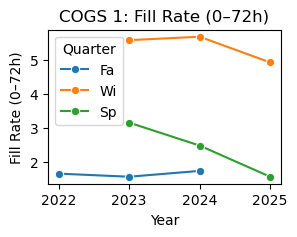

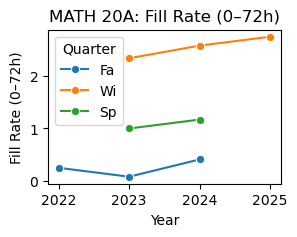

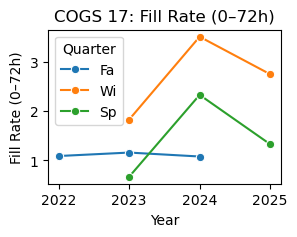

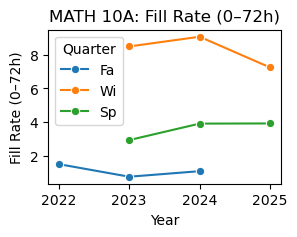

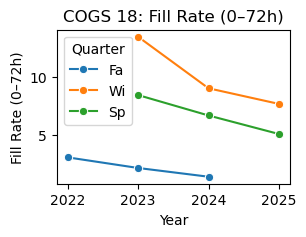

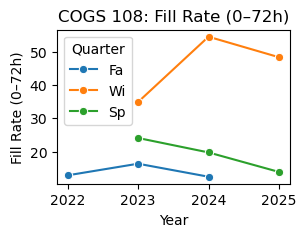

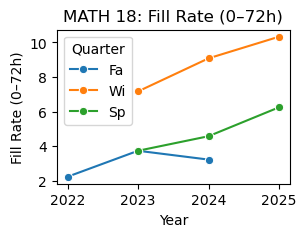

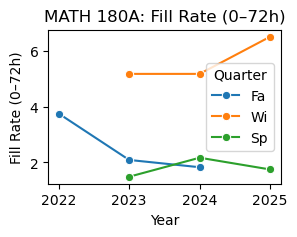

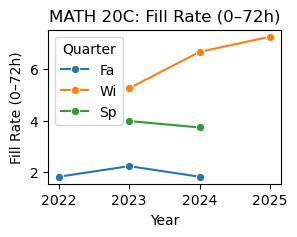

In [310]:
for course in ["COGS 1", "MATH 20A", "COGS 17", "MATH 10A", "COGS 18", "COGS 108","MATH 18","MATH 180A","MATH 20C"]:
    df_course = df[df["subj_course_id"] == course].copy()
    # extract year and season
    df_course["season"] = df_course["quarter"].str[:2]
    df_course["year"] = 2000 + df_course["quarter"].str[2:].astype(int)
    plt.figure(figsize=(3,2))

    sns.lineplot(
        data=df_course,
        x="year",
        y="fill_rate_0to72h",
        hue="season",
        marker="o"
    )
    plt.title(f"{course}: Fill Rate (0–72h)")
    plt.xlabel("Year")
    plt.ylabel("Fill Rate (0–72h)")
    plt.legend(title="Quarter")

    plt.show()

These plots highlight how enrollment patterns vary between quarters for the same course while remaining relatively stable within the same quarter across different years.

### Final Conclusion
Overall, the results across all subsets suggest that early enrollment behavior tends to be relatively consistent within the same quarter across different years, while variability between different quarters of the same course can be larger.

This pattern indicates that quarter-specific historical enrollment data may contain useful predictive signals. When forecasting enrollment demand for a course in a particular quarter, examining previous offerings of that course in the same quarter across past years may provide more relevant information than treating all past offerings equally.

These findings motivate the use of quarter-aware historical features when modeling the relationship between early enrollment metrics and final waitlist demand.